<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyPhysChem/blob/main/Ato1PS.ipynb)

</div>

In [ ]:
import requests

init_url = "https://raw.githubusercontent.com/rpoteau/pyPhysChem/main/colab_init.py"
try:
    r = requests.get(init_url, timeout=5)
    r.raise_for_status()
except requests.exceptions.RequestException:
    print("⚠️ Offline or connection error. Local setup assumed.")
else:
    exec(r.text)
    setup_environment()

In [ ]:
import pyphyschemtools as t4pPC
from pyphyschemtools import fg, hl, bg, color
t4pPC.init()
%matplotlib inline

__author__ = "Romuald Poteau, LPCNO (INSA-CNRS-UT lab, Toulouse, France)"

# Parcours spéciaux, Ato 1 (alias Ato1PS) : support numérique interactif

<div style="text-align:center">
<img src="MiscImages/logo_parcours_speciaux.png" width="400">
</div> 

## uma

### Définition, relation u ↔ g.mol<sup>-1<sup>

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

La masse d'un atome s'exprime en **unité de masse atomique unifiée** (u), définie comme $\frac{1}{12}$ de la masse d'un atome de carbone 12.

Numériquement, la masse molaire d'un élément en g·mol<sup>-1</sup> est égale à sa masse atomique en u : ainsi le carbone 12, de masse 12 u, a une masse molaire de ≈12 g·mol<sup>-1</sup>, à mieux que $10^{-9}$ près.

Cette correspondance u ↔ g·mol<sup>-1</sup> (à $10^{-9}$ près) découle de la définition de la mole ($M = N_A \times m_{\text{atome}}$) ; l'écart à l'égalité exacte entre u et masse molaire provient de la révision du SI de 2019 qui fixe désormais $N_A$ et la masse de l'uma indépendamment.

Pour les applications numériques, on va se servir du module `scipy.constants`. Il donne accès aux valeurs recommandées par le *Committee on Data of the International Science Council* (<a href="https://en.wikipedia.org/wiki/Committee_on_Data_of_the_International_Science_Council">CODATA</a>) pour les constantes physiques fondamentales (constante de Planck, charge élémentaire, masse de l'électron, nombre d'Avogadro, etc.). Les utiliser plutôt que des valeurs codées en dur garantit des calculs cohérents, précis et à jour, et évite les erreurs de recopie.

</div>

In [ ]:
import scipy.constants as sc
print(f'{hl.BOLD}uma: {sc.physical_constants["atomic mass constant"]}{hl.OFF}')
print(f'{hl.BOLD}constante de masse molaire: {sc.physical_constants["molar mass constant"]}{hl.OFF}')
print(f'{hl.BOLD}NA: {sc.physical_constants["Avogadro constant"]}{hl.OFF}')

print()
uma = sc.value("atomic mass constant")
NA = sc.value("Avogadro constant")
print("uma * NA = ", uma*NA,"kg.mol-1 = ",uma*NA*1000,"g.mol-1")

In [ ]:
from mendeleev import element
C = element("C")
print(C.atomic_weight, "u")    # 12.011
print()
for iso in C.isotopes:
    if iso.abundance is not None:
        print(f"{iso.mass_number:3d}  m = {iso.mass:.6f} u (≈ g.mol-1)   abondance = {iso.abundance}%")
print()
for iso in C.isotopes:
    if iso.abundance is None:
        print(f"{iso.mass_number:3d}  m = {iso.mass:.6f} u (≈ g.mol-1)   t1/2 = {iso.half_life} {iso.half_life_unit}")

### Préfixes

In [ ]:
import scipy.constants as sc

prefixes = {
    "quetta": sc.quetta, "ronna": sc.ronna, "yotta": sc.yotta, "zetta": sc.zetta,
    "exa": sc.exa, "peta": sc.peta, "tera": sc.tera, "giga": sc.giga,
    "mega": sc.mega, "kilo": sc.kilo, "hecto": sc.hecto, "deca": sc.deka,
    "deci": sc.deci, "centi": sc.centi, "milli": sc.milli, "micro": sc.micro,
    "nano": sc.nano, "pico": sc.pico, "femto": sc.femto, "atto": sc.atto,
    "zepto": sc.zepto, "yocto": sc.yocto, "ronto": sc.ronto, "quecto": sc.quecto,
}

for name, factor in prefixes.items():
    print(f"{name:8s} = {factor:g}")

## Constantes fondamentales

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

On va à nouveau se servir du module `scipy.constants`.

Chaque constante est accessible par son nom via `sc.value("...")` pour la valeur seule, ou via `sc.physical_constants["..."]` qui renvoie le triplet **(valeur, unité, incertitude)**.

</div>

In [ ]:
import scipy.constants as sc

In [ ]:
print(f'{hl.BOLD}Planck constant: {sc.physical_constants["Planck constant"]}{hl.OFF}')
print(f'{hl.BOLD}Reduced Planck constant: {sc.physical_constants["reduced Planck constant"]}{hl.OFF}')
print(f'{hl.BOLD}speed of light in vacuum: {sc.physical_constants["speed of light in vacuum"]}{hl.OFF}')
print()
print(f'{hl.BOLD}Elementary charge: {sc.physical_constants["elementary charge"]}{hl.OFF}')
print(f'{hl.BOLD}Electron mass: {sc.physical_constants["electron mass"]}{hl.OFF}')
print(f'{hl.BOLD}Proton mass: {sc.physical_constants["proton mass"]}{hl.OFF}')
print(f'{hl.BOLD}Neutron mass: {sc.physical_constants["neutron mass"]}{hl.OFF}')
print()
print(f'{hl.BOLD}Vacuum electric permittivity: {sc.physical_constants["vacuum electric permittivity"]}{hl.OFF}')
print()
print(f'{hl.BOLD}Infinite-mass Rydberg constant: {sc.physical_constants["Rydberg constant"]}{hl.OFF}')

h = sc.value("Planck constant")
hbar = sc.value("reduced Planck constant")
e = sc.value("elementary charge")
c = sc.value("speed of light in vacuum")
me = sc.value("electron mass")
mp = sc.value("proton mass")
mn = sc.value("neutron mass")
eps0 = sc.value("vacuum electric permittivity")
RH = sc.value("Rydberg constant")* (mp / (me + mp))
print(f'{hl.BOLD}H Rydberg constant: {RH} m^-1{hl.OFF}')

In [ ]:
print(mp/me)
print(mn/me)

## Petites applications

### Volume et rayon d'un atome

In [ ]:
import scipy.constants as sc
NA = sc.value("Avogadro constant")
Vm = 0.6 #g.mol-1
Vat = 0.6/NA
print(Vat,f"= {Vat:.1e} cm3")

## Isotopes

### Li

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Le lithium naturel est un mélange des deux isotopes <sup>6</sup>Li et 7 <sup>7</sup>Li dont les masses molaires sont respectivement 6,017 et 7,018 g.mol−1 . Sa masse molaire apparente (lithium à l’état naturel) est de 6,941
g.mol−1 . Quelle est en pourcentage sa composition isotopique ?
</div>

In [ ]:
import numpy as np

In [ ]:
t4pPC.centerTitle("Lithium")
M6 = 6.017
M7 = 7.018
M = 6.941

A = np.array([
             [M6,M7],
             [1,1]
             ])
y = np.array([M,1])
print(A)
print()
print(y)
p = np.linalg.solve(A, y)
print()
print(p[0]*100)
print(p[1]*100)

In [ ]:
p7 = (M-M6)/(M7-M6)
print(p7*100, 100*(1-p7))

### Cl

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Le chlore naturel, de masse atomique relative 35.459 u, est un mélange de deux isotopes <sup>35</sup>Cl et <sup>37</sup>Cl.

a) Quelles en sont les proportions respectives ? Quelle est la masse moyenne du dichlore (Cl2 ) ?
Données : Masse atomique du 35 Cl : 34.969 u ; Masse atomique du 37 Cl : 36.966 u

b) Il n’existe pas d’atome avec une masse atomique égale à 35.459 u de même qu’il n’existe pas non
plus de molécule Cl2 de masse 70.906. Le dichlore est un mélange de molécules ayant les diverses
compositions isotopiques possibles. Combien existent-il de types différents de molécules Cl2 et
quelle est leur masse ?

c) Quelles sont les proportions relatives des différentes molécules de Cl2 ?

d) Calculer la masse du dichlore à partir de la moyenne pondérée des masses moléculaires des
différents types de molécules de Cl2 . Quelle remarque pouvez-vous faire ?
</div>

In [ ]:
t4pPC.centerTitle("Chlore atomique")
t4pPC.centertxt("abondances isotopiques", style="grey")
M35 = 34.969
M37 = 36.966
M = 35.459

A = np.array([
             [M35,M37],
             [1,1]
             ])
y = np.array([M,1])
print(A)
print()
print(y)
p = np.linalg.solve(A, y)
print()
print(p[0]*100)
print(p[1]*100)
p35 = p[0]
p37 = p[1]

In [ ]:
t4pPC.centerTitle("Cl2")
p3535 = p35*p35*100
print("M 35 35 =",2*M35, "g.mol-1", "      p=",p3535,"%")

p3537 = 2*p35*p37*100
print("M 35 37 =",M35+M37, "g.mol-1", "      p=",p3537,"%")
p3737=p37*p37*100
print("M 37 37 =",2*M2, "g.mol-1", "      p=",p3737,"%")

print("Somme des pAB = ",p3535+p3537+p3737,"%")

print()
Mav = (p3535*(2*M35) + p3537*(M35+M37) + p3737*(2*M37))/100
print("M moyenne =",Mav, "g.mol-1")

In [ ]:
print(2*M)

### Liste des éléments qui ont un seul isotope stable

In [ ]:
from mendeleev import element

mono = []
for Z in range(1, 119):
    el = element(Z)
    naturels = [iso for iso in el.isotopes
                if getattr(iso, "abundance", None) is not None]
    if len(naturels) == 1:
        iso = naturels[0]
        hl_val  = getattr(iso, "half_life", None)
        hl_unit = getattr(iso, "half_life_unit", None)
        mono.append((Z, el.symbol, iso.mass_number, hl_val, hl_unit))

for Z, sym, A, hl_val, hl_unit in mono:
    demi = "stable" if hl_val is None else f"t½ = {hl_val} {hl_unit or ''}".strip()
    print(f"Z = {Z:3d}   {sym:2s}   A = {A:3d}   {demi}")
print(f"\n{len(mono)} éléments possédent un seul isotope naturel")

<div class="rq">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

Attention aux isotopes radiogéniques, qui excluent par exemple le Thorium de cette liste, à cause du 230-Th qui est issu de la désintégration de l'uranium, son "parent'. On trouve sur wikipedia:

"*In deep seawaters the isotope 230Th constitutes up to 0.02% of total thorium. This is because its parent uranium is generally soluble in the ocean, but 232Th is nearly insoluble and is precipitated; thus the isotopes continually produced from uranium is relatively enriched. **For this reason International Union of Pure and Applied Chemistry (IUPAC) reclassified thorium as a binuclidic element in 2013**; it had formerly been considered a mononuclidic element*"
</div>

In [ ]:
from mendeleev import element

el = element("Th")
print(f"{el.symbol} — {el.name} (Z = {el.atomic_number})\n")
print(f"{'A':>4} {'abondance':>12} {'demi-vie':>18}")
print("-"*36)
for iso in sorted(el.isotopes, key=lambda i: i.mass_number):
    ab = "" if iso.abundance is None else f"{iso.abundance} %"
    if getattr(iso, "half_life", None) is None:
        hl = "stable"
    else:
        hl = f"{iso.half_life} {getattr(iso, 'half_life_unit', '') or ''}".strip()
    print(f"{iso.mass_number:>4} {ab:>12} {hl:>18}")

## Atome d'hydrogène

<div class="rq">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

Initialiser d'abord les constantes fondamentales.
</div>

### Modèle de Bohr

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

Le rayon des orbites du modèle de Bohr dépend d'un nombre entier *n* &ge; 1:

$$r_n = \frac{4\pi\varepsilon_0\,\hbar^2}{m_e\, e^2}\,\frac{n^2}{Z} = a_0\,\frac{n^2}{Z}$$

où $a_0$ est appelé le rayon de Bohr 
</div>

In [ ]:
import math
a0 = 4*math.pi*eps0*hbar**2/(me*e**2)
print(a0, "m = ",a0/1e-10,"ansgtrom = ",a0/1e-12,"pm")

print(f'{hl.BOLD}Bohr radius: {sc.physical_constants["Bohr radius"]}{hl.OFF}')

### Propriétés d'absorption et d'émission de H et des hydrogénoïdes

#### Calcul des premiers niveaux d'énergie de H

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

The solutions to the Schrödinger equation for hydrogenoids are analytical, giving a simple expression for the energy levels:

$$E_n = - \frac{E_{i}}{n^2}Z^2$$

where

$$E_{i}=\frac{1}{2}\frac{\mu_{\mathrm{H}}e^{4}}{\left(\hbar\times4\pi\varepsilon_{0}\right)^{2}}$$

is the ionization energy for the hydrogen atom

</div>

In [ ]:
import numpy as np

t4pPC.centerTitle("calcul de la masse réduite de H")
muH = (me*mp)/(me+mp)
print(f'{hl.BOLD}Hydrogen atom reduced mass: {muH} kg{hl.OFF}')
print(f'{hl.BOLD}Hydrogen atom reduced mass/electron mass: {muH/me}{hl.OFF}')

t4pPC.centerTitle("calcul de l'énergie d'ionisation de H")
pi = np.pi
Ei = 0.5*muH*e**4/((4*pi*eps0)**2*hbar**2)
Ei_eV = Ei/e
print(f"{fg.BLUE}{hl.BOLD}Énergie d'ionisation de H : {Ei:.6e} J{hl.OFF}")
print(f"{fg.BLUE}{hl.BOLD}Énergie d'ionisation de H : {Ei_eV:.6} eV{hl.OFF}")

t4pPC.centerTitle("conversion  de RH m-1 > eV")
RH_eV = h*c*RH/e
print(f"{fg.BLUE}{hl.BOLD}Constante de Rydberg pour H, convertie en eV : {RH_eV:.6} eV{hl.OFF}")

In [ ]:
t4pPC.centerTitle("définition de En")

def En(n,Z=1):
    '''
    Énergie du niveau n d'un atome hydrogénoïde (modèle de Bohr / solution
    analytique de l'équation de Schrödinger), en joules.

    E_n = -Ei * Z^2 / n^2,  avec  Ei = (1/2) * muH * e^4 / ((4*pi*eps0)^2 * hbar^2)

    input:
    - n = nombre quantique principal (entier > 0)
    - Z = numéro atomique (défaut: 1 pour l'hydrogène)

    output:
    - énergie du niveau n, en joules (valeur négative, état lié)

    remarque: utilise la masse réduite muH, donc l'énergie d'ionisation Ei
    correspond à l'hydrogène réel (et non à l'approximation noyau infiniment lourd).
    '''
    pi = np.pi
    Ei = 0.5*muH*e**4/((4*pi*eps0)**2*hbar**2)
    return -Ei*Z**2/n**2

In [ ]:
t4pPC.centerTitle("absorption d'un photon depuis n=1")
for n in range(2,11):
    DeltaE = En(n)-En(1)
    print(f"{n:2d}  {En(n)/e:.3f} eV.      1 -> {n}: {DeltaE/e:.3f}eV.        lambda = {1e9*h*c/DeltaE:.2f} nm")

#### Séries

<div class="exE">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercise</b></span></td></tr></table>

- Calculate all transition energies (in eV) and transition wavelengths (in nm) of the [Lyman, Balmer, Paschen, Brackett, Pfund and Humphreys series](https://en.wikipedia.org/wiki/Hydrogen_spectral_series) in the range $n=1 \leftarrow n=12$
- Calculate as well the limit value for each series, in nm
</div>

In [ ]:
nlevels = 12

series = {
    1: "Lyman",
    2: "Balmer",
    3: "Paschen",
    4: "Brackett",
    5: "Pfund",
    6: "Humphreys",
}

for n2, name in series.items():
    lambda_inf = -1e9 * h*c / (En(n2))     # limite de la série (n1 -> inf)
    print(f"\n{hl.BOLD}{fg.BLUE}{name}. lambda_inf = {lambda_inf:.5g} nm{hl.OFF}")
    for n1 in range(n2+1, nlevels+1):
        Ediff = En(n1) - En(n2)
        wavelength = 1e9 * h*c / Ediff
        frequency = c/(wavelength/1e9)
        print(f"{n1:2} --> {n2:2} DE = {Ediff/e:6.3f} eV   lambda = {wavelength:8.2f} nm     nu = {frequency:.2e} Hz")

In [ ]:
R_H = 10967758 #m-1
R_H*1e-9

#### Transitions entre états. Inversion de l'équation de Rydberg avec SymPy

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

$$\varepsilon_{photon} = \frac{hc}{\lambda} = E(n_2) - E(n_1) = R_H\left(\frac{1}{n_1^2} - \frac{1}{n_2^2}\right), \quad n_2 > n_1$$
</div>
<br>
<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Si un atome d’hydrogène dans son état fondamental absorbe un photon de longueur d’onde λ1 puis émet un photon de longueur d’onde λ2 , sur quel niveau l’électron se trouve-t-il après cette émission ?

λ1 = 97,23 nm et λ2= 1870 nm
</div>

In [ ]:
t4pPC.centerTitle("absorption depuis n=1. Approche numérique")

n2_abs = (1/(1-1/(97.23e-9*RH)))**(0.5)
print(n2_abs)

In [ ]:
t4pPC.centerTitle("émission depuis n = 4. Approche numérique (1)")
for n1 in range(4,1,-1):
    for n2 in range(n1-1,0,-1):
        DeltaE = En(n1)-En(n2)
        print(f"{n1:2d} -> {n2:2d}  {DeltaE/e:.3f}eV.        lambda = {1e9*h*c/DeltaE:.2f} nm")
    print()

In [ ]:
t4pPC.centerTitle("émission depuis n = 4. Approche numérique (2)")

n2_em = (1/(1/16+1/(1870e-9*RH)))**(0.5)
print(n2_em)

In [ ]:
t4pPC.centerTitle("Approche symbolique (CAS) avec SymPy")
import sympy as sp
h_, c_, Ei_, n1_, n2_, lam_ = sp.symbols('h c Ei n1 n2 lambda', positive=True)

eq = sp.Eq(h_*c_/lam_, Ei_*(1/n1_**2 - 1/n2_**2))
sol_n2 = sp.solve(eq, n2_)
print(sol_n2)
sol_n2 = sol_n2[1]
sol_n2


In [ ]:
sol_n1 = sp.solve(eq, n1_)
sol_n1


In [ ]:
f_n2 = sp.lambdify((h_, c_, Ei_, n1_, lam_), sol_n2)
f_n1 = sp.lambdify((h_, c_, Ei_, n2_, lam_), sol_n1)

In [ ]:
t4pPC.centertxt("niveau d'arrivée",fgc="black",bgc="#dddddd", weight="bold")
n_abs = f_n2(h,c,Ei,1,97.23e-9)
n_abs

In [ ]:
t4pPC.centertxt("niveau émissif",fgc="black",bgc="#dddddd", weight="bold")
n_em = f_n1(h,c,Ei,n_abs,1870e-9)
n_em

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Si un atome d’hydrogène dans son état fondamental absorbe un photon de longueur d’onde λ1 puis émet un photon de longueur d’onde λ2 , sur quel niveau l’électron se trouve-t-il après cette émission ?

λ1 = 97,23 nm et λ2= 78,15 nm
</div>
<br>
<div class="rq">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

E2 > E1 ! Impossible. Qu'est-ce que ça donne numériquement ? Voir ci-dessous
</div>

In [ ]:
t4pPC.centertxt("niveau émissif",style="grey")
n_em = f_n1(h,c,Ei,n_abs,78.15e-9)
n_em

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Un échantillon d’atomes d’hydrogène pris à l’état fondamental est soumis à une énergie de 12,10 eV
par atome. La lumière émise par cet échantillon est analysée par un spectrographe.

(a) A quelles transitions correspondent les raies observées (faire un schéma) ?

(b) Quelle est la longueur d’onde de la raie de plus grande fréquence ?

(c) Quelle est la quantité d’énergie que doit absorber une mole d’atomes d’hydrogène ainsi excités pour
passer de cet état excité à l’état ionisé ?
</div>

In [ ]:
t4pPC.centerTitle("(a) niveau émissif")
(1/(1-12.10/13.598))**0.5

In [ ]:
t4pPC.centerTitle("(b) longueur d'onde la raie de plus grande fréquence")
print(RH)
lambda_inv = RH*(1-1/9)
print(f"{lambda_inv:.7e} m-1")
print(f"{1e9/lambda_inv:.1f} nm")

In [ ]:
t4pPC.centerTitle("(c) énergie nécessaire pour passer à l'état ionisé")
print(-En(3)/e)
print(-En(3)*NA)

<div class='ex'>

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>
Le spectre de l’hydrogène présente une raie à 434,1 nm correspondant à une transition x → 2.
Déterminer la valeur de x.
</div>

In [ ]:
RH=1.0967758e-2 #nm-1
x2 = RH/(RH/4-1/434.1)
print(x2)
print(np.sqrt(x2))

#### Hydrogénoïdes

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

La figure ci-dessous représente le spectre d’émission d’un hydrogénoı̈de en phase gazeuse. Toutes les raies
résultent de transitions électroniques d’états excités de retour à l’état n = 2.

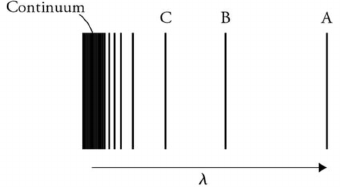

1. À quelles transitions électroniques correspondent les raies B et C ?
2. Si la longueur d’onde de C est 27,1 nm, calculez les longueurs d’onde des raies A et B.
3. Calculez l’énergie nécessaire pour enlever l’électron de cet ion à partir du niveau n = 4.
4. Quelle est la signification du continuum ?
</div>

In [ ]:
t4pPC.centerTitle("2. Longueurs d'onde de A & B")
t4pPC.centertxt("Valeur de Z",style="grey")
Z=(1/(RH*27.1e-)*100/21)**0.5
print(Z)

In [ ]:
t4pPC.centertxt("longueurs donde de A & B",style="grey")
lambda_A_inv = RH*16*(1/4-1/9)
print(f"1/lambda A = {lambda_A_inv:.7e} m-1")
print(f"lambda A = {1/lambda_A_inv*1e9:.1f} nm")

print()
lambda_B_inv = RH*16*(1/4-1/16)
print(f"1/lambda B = {lambda_B_inv:.7e} m-1")
print(f"lambda B = {1/lambda_B_inv*1e9:.1f} nm")

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>
    
Déterminer l’énergie d’ionisation de 1 H, de deuxième ionisation de 2 He, de troisième ionisation de 3 Li et de
quatrième ionisation de 4Be. Expliquer pourquoi ces énergies sont croissantes
</div>

In [ ]:
for Z in range(1,5):
    print(f"Z={Z:3}  Ei_{Z} = {-En(1,Z)/e:.4e} eV")

#### Probabilité de Boltzmann des transitions

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

**Pourquoi ne voit-on presque pas l'hydrogène dans le spectre du Soleil ?**

##### Contexte

Les étoiles sont composées à environ $74\,\%$ (en masse) d'hydrogène. On s'attend donc à ce que les raies de l'hydrogène dominent leur spectre d'absorption. Pourtant, dans le spectre solaire, les raies visibles de l'hydrogène (série de Balmer) sont modestes face aux raies métalliques (Fe, Na, …), alors que le fer est $\sim 10^5$ fois moins abondant. Cet exercice élucide ce paradoxe apparent avec quelques arguments semi-quantitatifs.

##### Données

- Énergie des niveaux hydrogénoïdes :
$$E_{n \text{/eV}} = -13{,}598\,\frac{Z^2}{n^2}$$
- Dégénérescence d'un niveau : $g_n = 2n^2$
- Loi de Boltzmann (équilibre thermodynamique local) :
$$\frac{p(n_2)}{p(n_1)} = \frac{g_2}{g_1}\,\exp\!\left(-\frac{E_{n_2}-E_{n_1}}{k_B T}\right)$$
- Températures de surface : $T_\text{Soleil} = 5772$ K ; $T_\text{Sirius} = 9845$ K


##### Questions

**1. Physique et ordres de grandeur**

(a) Calculer $\Delta E = E_2 - E_1$ pour l'hydrogène ($Z = 1$), en eV. Justifier $g_2 = 8$ en décomptant les états $(\ell, m_\ell, m_s)$. 

(b) Calculer $p_2/p_1$ pour le Soleil et Sirius, et le relier à l'intensité des raies de Balmer dans chacun de ces deux astres.

(c) Vers quel domaine spectral (et quelle série) absorbent les atomes restants, ceux du fondamental ? Pourquoi ces raies ne sont-elles pas observées depuis le sol ?

**2. Pour aller plus loin**

(a) Tracer $p_2/p_1$ en fonction de $T$ entre $3000$ K et $30\,000$ K (échelle log en ordonnée). Commenter la croissance.

(b) Sur le même graphe, ajouter $p_{10}/p_1$. Interpréter le roisement des deux courbes : quel terme domine en dessous du croisement, lequel domine au-dessus ?

(c) *Question ouverte*. Que suggère ce croisement sur le devenir de la population aux très hautes températures ? Vers quels niveaux "fuit" la population quand $T$ augmente, et qu'est-ce que cela annonce quant au sort de l'atome d'hydrogène et à l'observation des raies de l'hydrogène dans un spectre d'absorption des étoiles "chaudes" ?
</div>


In [ ]:
t4pPC.centerTitle("définition de En & p(n)")

def En(n,Z=1):
    '''
    Énergie du niveau n d'un atome hydrogénoïde (modèle de Bohr / solution
    analytique de l'équation de Schrödinger), en joules.

    E_n = -Ei * Z^2 / n^2,  avec  Ei = (1/2) * muH * e^4 / ((4*pi*eps0)^2 * hbar^2)

    input:
    - n = nombre quantique principal (entier > 0)
    - Z = numéro atomique (défaut: 1 pour l'hydrogène)

    output:
    - énergie du niveau n, en joules (valeur négative, état lié)

    remarque: utilise la masse réduite muH, donc l'énergie d'ionisation Ei
    correspond à l'hydrogène réel (et non à l'approximation noyau infiniment lourd).
    '''
    muH=me*mp/(me+mp)
    pi = np.pi
    Ei = 0.5*muH*e**4/((4*pi*eps0)**2*hbar**2)
    return -Ei*Z**2/n**2

def pB(n1=1, n2=2, Z=1, T=5772):
    """
    Rapport de population de Boltzmann entre deux niveaux de l'atome
    hydrogénoïde, N(n2)/N(n1), à l'équilibre thermodynamique local.

        N(n2)/N(n1) = (g2/g1) * exp(-(E_{n2} - E_{n1}) / (kB * T))

    Pour un ion hydrogénoïde, E_n = -13.6 * Z^2 / n^2 (eV) et la
    dégénérescence d'un niveau est g_n = 2 * n^2 (spin!!).

    Parameters
    ----------
    n1 : int, optional
        Nombre quantique principal du niveau de départ (bas). Défaut 1.
    n2 : int, optional
        Nombre quantique principal du niveau d'arrivée (haut). Défaut 2.
    Z : int, optional
        Numéro atomique (1 pour H). Défaut 1.
    T : float, optional
        Température en kelvins. Défaut 5772 K (Soleil).
    degeneracy : bool, optional
        Si True, inclut le rapport des poids statistiques g2/g1.
        Si False, renvoie le seul facteur de Boltzmann (population
        par état individuel). Défaut True.

    Returns
    -------
    float
        Rapport de population N(n2)/N(n1) (sans dimension).

    Examples
    --------
    >>> pB(1, 2, T=5772)          # niveau n=2 vs n=1 dans le Soleil
    ~5e-9
    """
    import scipy.constants as sc
    kB = sc.value("Boltzmann constant")   # J K-1
    DeltaE = En(n2, Z) - En(n1, Z)        # > 0 pour n2 > n1
    ratio = np.exp(-DeltaE / (kB * T))
    ratio *= (2 * n2**2) / (2 * n1**2)
    return ratio

print(f'{hl.BOLD}Boltzmann constant: {sc.physical_constants["Boltzmann constant"]}{hl.OFF}')
kB = sc.value("Boltzmann constant") #J.K-1
kB_eV = kB/e
T_soleil = 5772
T_Sirius = 9845
print(kB_eV, 1/kB_eV)  
print()
print(f"Énergie thermique k_B·T (Soleil)  = {kB_eV*T_soleil:.4f} eV")
print(f"Énergie thermique k_B·T (Sirius)  = {kB_eV*T_Sirius:.4f} eV")
print()
print(f"Probabilité de transition de 1 > 2 à la surface du soleil = {pB(1,2,1,T_soleil):.0e}")
print(f"Probabilité de transition de 1 > 2 à la surface de Sirius = {pB(1,2,1,T_Sirius):.0e}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

kB_eV = sc.value("Boltzmann constant in eV/K")   # eV/K
T = np.linspace(3000, 30000, 500)

fig, ax1 = plt.subplots()

# Axe principal : rapport de population (échelle log)
color1 = "tab:blue"
ax1.semilogy(T, pB(1, 2, 1, T), color=color1, label="n2=2")
ax1.set_xlabel("Température (K)")
ax1.set_ylabel(r"$p_{n2}/p_1$", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(True, which="both", alpha=0.3)

color2 = "tab:red"
ax1.semilogy(T, pB(1, 10, 1, T), color=color2, label="n2=10")

plt.title("Populations relatives")
fig.legend()
fig.tight_layout()
plt.show()

### Opérateur hamiltonien

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

The Schrödinger equation allows one to calculate the stationary states and also the time evolution of quantum systems. Exact analytical answers are available for the nonrelativistic hydrogen atom. In short, the time-independent Schrödinger Equation for the hydrogen atom is conveniently written and solved in spherical coordinates:

$$\hat{H}(r,\theta,\varphi)\psi(r,\theta,\varphi)=E\psi(r,\theta,\varphi)$$

with $\hat{H}=\hat{T}+\hat{V}$, where

$$\hat{V} = -\frac{e^{2}}{4\pi\varepsilon_{0}}\frac{1}{r}$$

is the position-dependent potential of the electron "cruising" under the influence of the proton, and

$$ \hat{T}=-\frac{\hbar^{2}}{2\mu_\mathrm{H}}\nabla^{2} $$

with

$$\nabla^{2}=\frac{1}{r^{2}}\left[\frac{\partial}{\partial r}\left(r^{2}\frac{\partial}{\partial r}\right)+\Lambda^{2}\right]$$

$\mu_\mathrm{H}$ is the reduced mass for the electron: $\mu_\mathrm{H} = m_e m_p / (m_e+m_p)$

and $\Lambda^2$ is the Legendre operator:

$$\Lambda^{2}=\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\frac{\partial}{\partial\theta}\right)+\frac{1}{\sin^{2}\theta}\frac{\partial^{2}}{\partial\varphi^{2}}$$

It can be demonstrated that $\psi(r,\theta,\varphi)$ is a product wavefunction, made of a radial part $R_{n\ell}(r)$ and an angular part, the spherical harmonic $Y_\ell^m(\theta,\varphi)$ functions.

$Y_\ell^m(\theta,\varphi)$ are the normalized eigenvectors of the $\Lambda^2$ operator:

$$\Lambda^{2}Y_\ell^m(\theta,\varphi)=-l(l+1)Y_\ell^m(\theta,\varphi)$$

and $R_{n\ell}(r)$ are solution of a radial equation, which eigenvalue is the energy for the hydrogen atom:

$$\left(-\frac{\hbar^{2}}{2\mu}\left[\frac{1}{r^{2}}\frac{\partial}{\partial r}\left(r^{2}\frac{\partial}{\partial r}\right)-\frac{l(l+1)}{r^{2}}\right]-\frac{e^{2}}{4\pi\varepsilon_{0}}\frac{1}{r}\right)R_{n\ell}(r)=E_{n}R_{n\ell}(r)$$

</div>
<br>

<div class="rqE">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Pay Attention</b></span></td></tr></table>

<span style="color:red">**In summary...**</span>

Any $\psi_{n\ell m}(r,\theta,\varphi)=R_{n\ell}(r)Y_\ell^m(\theta,\varphi)$ wavefunction is an eigensolution of $\hat{H}(r,\theta,\varphi)\psi_{n\ell m}(r,\theta,\varphi)=E_n\psi_{n\ell m}(r,\theta,\varphi)$, with

$$\hat{H}=-\frac{\hbar^{2}}{2\mu_\mathrm{H}}\nabla^{2}-\frac{e^{2}}{4\pi\varepsilon_{0}}\frac{1}{r}$$

$$\hat{H}=-\frac{\hbar^{2}}{2\mu_\mathrm{H}}\frac{1}{r^{2}}\left[\frac{\partial}{\partial r}\left(r^{2}\frac{\partial}{\partial r}\right)+\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\frac{\partial}{\partial\theta}\right)+\frac{1}{\sin^{2}\theta}\frac{\partial^{2}}{\partial\varphi^{2}}\right]-\frac{e^{2}}{4\pi\varepsilon_{0}}\frac{1}{r}$$

</div>

#### Solutions pré-définies dans la bibliothèque `SymPy`

##### État fondamental

In [ ]:
import sympy as sp
import scipy.constants as sc
from sympy.physics.hydrogen import Psi_nlm, R_nl
from sympy import Ynm, Znm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
sp.init_printing(use_unicode=True)

pi = sp.pi
r_ = sp.Symbol("r", positive=True)
phi_ = sp.Symbol("phi", real=True)
theta_ = sp.Symbol("theta", real=True)

In [ ]:
t4pPC.centerTitle("ψ_100")
Psi_nlm(1,0,0,r_,phi_,theta_)
t4pPC.centerTitle("R_10")
R_nl(1,0,r_)
t4pPC.centerTitle("Y_00")
Ynm(0,0,theta_,phi_)
Ynm(0,0,theta_,phi_).expand(func=True)
t4pPC.centerTitle("S_00")
Znm(0,0,theta_,phi_)
Znm(0,0,theta_,phi_).expand(func=True)
t4pPC.centerTitle("R_10 . Y_00")
R_nl(1,0,r_)*Ynm(0,0,theta_,phi_).expand(func=True)

<div class="rqE">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Pay Attention</b></span></td></tr></table>

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

To expand special functions `F` in terms of some identities, `use expand_func(F)` or `F.expand(func=True)`.

See the [**Simplification** tutorial](https://docs.sympy.org/latest/tutorials/intro-tutorial/simplification.html#expand-func) on the `SymPy` website.
</div>

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Vérifier que les fonctions $R$, $Y$ et $\psi$ sont normées indépendamment.
</div>


In [ ]:
def normR(f):
    from sympy import oo
    dv = r_**2
    norm = sp.integrate(f.conjugate()*f*dv,(r_,0,oo))
    return norm

def normY(f):
    dv = sp.sin(theta_)
    norm = sp.integrate(f.conjugate()*f*dv,(theta_,0,sp.pi),(phi_,0,2*sp.pi))
    return norm

def norm(f):
    from sympy import oo
    dv = r_**2*sp.sin(theta_)
    norm = sp.integrate(f.conjugate()*f*dv,(r_,0,oo),(theta_,0,sp.pi),(phi_,0,2*sp.pi))
    return norm

normR(R_nl(1,0,r_))
normY(Ynm(0,0,theta_,phi_).expand(func=True))
norm(Psi_nlm(1,0,0,r_,phi_,theta_))

##### Expression des premiers états 

In [ ]:
from IPython.display import display, Math

def show_eq(latex_name, *exprs):
    """Affiche 'nom = expr1 = expr2 = ...' en LaTeX."""
    rhs = " = ".join(sp.latex(e) for e in exprs)
    display(Math(f"{latex_name} = {rhs}"))

n_max = 4   # couches à afficher : n = 1, 2 (mets 3 pour ajouter la couche M)

for n in range(1, n_max+1):
    t4pPC.centerTitle(f"Couche n={n}")
    for l in range(0, n):                 # l = 0 .. n-1
        t4pPC.centertxt(f"Sous-couche l={l}", style="grey")
        # --- partie radiale : ne dépend que de (n, l) ---
        show_eq(f"R_{{{n}{l}}}", R_nl(n, l, r_))

        for m in range(-l, l+1):
            show_eq(f"Y_{{{l}}}^{{{m}}}", Ynm(l, m, theta_, phi_).expand(func=True))
            exprS = Znm(l, m, theta_, phi_).expand(func=True)
            show_eq(f"S_{{{l}}}^{{{m}}}", exprS, sp.simplify(exprS))
            show_eq(f"\\psi_{{{n}{l}{m}}}", Psi_nlm(n, l, m, r_, phi_, theta_))
            show_eq(f"R_{{{n}{l}}}\\timesS_{{{l}}}^{{{m}}}", Psi_nlm(n, l, m, r_, phi_, theta_))
            if l > 0 and m!=l: print();print()

#### Vérification que psi_100 est fonction propre de H

<div class="rq">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

Initialiser d'abord les constantes fondamentales.
</div>

<div class="intro">

<table width="100%" cellpadding="6"><tr><td bgcolor="#e6e6e6"><span style="color:#000000">📖 <b>Introduction</b></span></td></tr></table>

Let's now write the Hamiltonian operator in atomic units. The Hartree atomic units are a system of natural units of measurement which is especially convenient for calculations in atomic physics and related scientific fields, such as computational chemistry and atomic spectroscopy. 
By definition, each of the following four fundamental physical constants is expressed as the numeric value 1:
- reduced Planck constant, $\hbar \rightarrow 1$
- electron rest mass, $m_e\rightarrow1$
- elementary charge, $e\rightarrow1$
- Coulomb constant, $k_e\rightarrow1$

The hamiltonian becomes:

$$\hat{H}=-\frac{1}{2\mu_{\mathrm{H}/m_{e}}r^{2}}\left[\frac{\partial}{\partial r}\left(r^{2}\frac{\partial}{\partial r}\right)+\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\frac{\partial}{\partial\theta}\right)+\frac{1}{\sin^{2}\theta}\frac{\partial^{2}}{\partial\varphi^{2}}\right]-\frac{1}{r}$$

where $\mu_{\mathrm{H}/m_{e}}$ is the reduced mass of the hydrogen atom in atomic units, $\mu_{\mathrm{H}/m_{e}}=\mu_\mathrm{H}/m_{e}\approx0.99...$


and $\frac{1}{r^2}\left[\frac{\partial}{\partial r}\left(r^{2}\frac{\partial}{\partial r}\right)+\frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\frac{\partial}{\partial\theta}\right)+\frac{1}{\sin^{2}\theta}\frac{\partial^{2}}{\partial\varphi^{2}}\right]$ is the laplacian $\Delta$, *i.e.* $\nabla^2$ 

</div>
<br>
<div class="rqE">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Pay Attention</b></span></td></tr></table>

The reduced mass in atomic units is not exactly 1. The following expression for the hamiltonian, often given in textbooks, turns out to be an approximation 

$$\hat{H}=-\frac{1}{r}\nabla^{2}-\frac{1}{r}$$

</div>

In [ ]:
import sympy as sp
from sympy.physics.hydrogen import Psi_nlm
sp.init_printing(use_unicode=True)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pi = sp.pi
r_ = sp.Symbol("r", positive=True)
phi_ = sp.Symbol("phi", real=True)
theta_ = sp.Symbol("theta", real=True)
mu_ = sp.Symbol("mu", positive=True)

muH = me*mp/(me+mp)
print(f"{muH=} kg")
print(f"{muH/me=} (exact reduced mass in hartree)")

In [ ]:
import numpy as np
import sympy as sp

# insert your code here

def nabla2(f):
    T1 = sp.diff(f, r_, 1)
    T1 = sp.diff(T1*r_**2, r_, 1)
    T2 = sp.diff(f, theta_, 1)
    T2 = sp.diff(T2*sp.sin(theta_), theta_, 1)
    T2 = T2/sp.sin(theta_)
    T3 = sp.diff(f, phi_, 2)
    T3 = T3/(sp.sin(theta_)**2)
    return (T1 + T2 + T3)/r_**2
    
def H(f):
    return -nabla2(f)/(2*mu_) - f/r_
    
def norm(f):
    import sympy as sp
    from sympy import oo
    dv = r_**2*sp.sin(theta_)
    norm = sp.integrate(f.conjugate()*f*dv,(r_,0,oo),(theta_,0,sp.pi),(phi_,0,2*sp.pi))
    return norm    

def En(f,prt=False):
    import sympy as sp
    from sympy import oo
    dv = r_**2*sp.sin(theta_)
    norm(f)
    if (prt): print()
    if (prt): print(f"{hl.BOLD}{fg.BLUE}ψ{hl.BOLD}")
    if (prt): display(f)
    if (prt): print(f"Norm of ψ: {norm(f)}")
    PsiHPsi = sp.simplify(f.conjugate()*H(f))
    if (prt): print(f"{hl.BOLD}{fg.BLUE}ψ*Hψ{hl.BOLD}")
    if (prt): display(PsiHPsi)
    if (prt): print(f"{hl.BOLD}{fg.BLUE}(ψ*Hψ)(r^2sin(θ)){hl.BOLD}")
    PsiHPsi_dv = sp.simplify(PsiHPsi*dv)
    if (prt): display(PsiHPsi_dv)
    E=sp.integrate(PsiHPsi_dv,(r_,0,oo),(theta_,0,sp.pi),(phi_,0,2*sp.pi))
    return E

In [ ]:
t4pPC.centerTitle("Fonction d'onde ψ100")
print(f"ψ100 : {Psi_nlm(1,0,0,r_,phi_,theta_)}")
Psi_nlm(1,0,0,r_,phi_,theta_)
print()
t4pPC.centerTitle("E=f(μ)")
E1 = En(Psi_nlm(1,0,0,r_,phi_,theta_),False)
E1
t4pPC.centerTitle("E=f(μ=1), aka approximation masse infinie")
E1.subs(mu_,1)
t4pPC.centerTitle("E=f(μ exact)")
E1.subs(mu_,muH/me)

### Densité de probabilité de présence radiale

#### Fonctions ns et 2pz

<div class="ex">

<table width="100%" cellpadding="6"><tr><td bgcolor="#d8edf4"><span style="color:#0D47A1">📝 <b>Exercice</b></span></td></tr></table>

Une fonction d’onde $\psi_{n,l,m}(r,\theta,\phi)$ peut se mettre sous la forme du produit de deux fonctions indépendantes,
les parties radiales et angulaires :  $\psi_{n,l,m}(r,\theta,\phi)=R_{n,l}(r)Y_{l,m}(\theta,\phi)$. On admettra que $R_{n,l}^2(r)r^2$ représente la
densité de probabilité de l’électron à une distance r du noyau, quelles que soient les valeurs de $\theta$ et $\phi$. Cette
quantité est appelée denisté de probabilité de présence radiale de l’électron.

1. Commenter les graphes de densité de probabilité de présence radiale donnés dans les annexes dans le
cas de l’hydrogène, en particulier, relever graphiquement le maximum pour l’orbitale 1s.

2.  Retrouver cette valeur par le calcul, connaissant l'expression de $R_{1,0}(r)$

3.  Expliquer en quoi la distance $r=2a_0$ est particulière pour l’orbitale atomique 2s, connaissant l'expression de $\psi_{2,0,0}$

4.  Montrer que la densité de probabilité d’un électron décrit par l’orbitale atomique 2pz dans le plan (xOy) est nulle, connaissant l'expression de $\psi_{2,1,0}$

5.  A partir de l’expression de $\psi_{2,1,0}$, montrer que la densité de probabilité d’un électron décrit par
l’orbitale atomique 2pz est de symétrie de révolution autour de l’axe z.
</div>

In [ ]:
import numpy as np
import sympy as sp
import scipy.constants as sc
from sympy.physics.hydrogen import Psi_nlm, R_nl
from sympy import Ynm, Znm
sp.init_printing(use_unicode=True)

import matplotlib.pyplot as plt

In [ ]:
pi = sp.pi
r_ = sp.Symbol("r", positive=True)
phi_ = sp.Symbol("phi", real=True)
theta_ = sp.Symbol("theta", real=True)

t4pPC.centerTitle("Question 1 (P_nl)")
P10 = R_nl(1, 0, r_)**2 * r_**2
P20 = R_nl(2, 0, r_)**2 * r_**2
P30 = R_nl(3, 0, r_)**2 * r_**2
P40 = R_nl(4, 0, r_)**2 * r_**2
display(P10)
display(P20)
display(P30)
display(P40)

f_P10 = sp.lambdify(r_, P10, "numpy")
f_P20 = sp.lambdify(r_, P20, "numpy")
f_P30 = sp.lambdify(r_, P30, "numpy")
f_P40 = sp.lambdify(r_, P40, "numpy")

r = np.linspace(0, 40, 400)           # r en unités de a0
plt.figure(figsize=(7, 4))
plt.plot(r, f_P10(r), lw=2)
plt.plot(r, f_P20(r), lw=2)
plt.plot(r, f_P30(r), lw=2)
plt.plot(r, f_P40(r), lw=2)
plt.xlabel(r"$r / a_0$")
plt.ylabel(r"$P_{n,l}(r) = r^2\,R_{n,l}^2$")
plt.title("Densité de probabilité radiale de l'orbitale 1s")
plt.grid(alpha=0.3)
plt.show()

<div class="rq">

<table width="100%" cellpadding="6"><tr><td bgcolor="#fde9e9"><span style="color:#B71C1C">⚠️ <b>Remarque</b></span></td></tr></table>

Une densité radiale n'est jamais sans unité : c'est une probabilité par unité de longueur. Si on revient aux unités SI, c'est une unité en $a_0^{-1}$.
</div>

In [ ]:
t4pPC.centerTitle("Question 2, r_max P10")
dP10 = sp.diff(P10, r_)
sol = sp.solve(sp.Eq(dP10, 0), r_)
display(sol)
display([P10.subs(r_, s) for s in sol])

t4pPC.centerTitle("Question 2 subsidiaire, r_max P20")
dP20 = sp.diff(P20, r_)
sol = sp.solve(sp.Eq(dP20, 0), r_)
display(sol)
racines = sorted(sp.re(sp.N(s)) for s in sol)
display(racines)
display([P20.subs(r_, s) for s in racines])

t4pPC.centerTitle("Question 2 subsidiaire, r_max P30")
dP30 = sp.diff(P30, r_)
sol = sp.solve(sp.Eq(dP30, 0), r_)
display(sol)
racines = sorted(sp.re(sp.N(s)) for s in sol)
display(racines)
display([P30.subs(r_, s) for s in racines])

t4pPC.centerTitle("Question 2 subsidiaire, r_max P40")
dP40 = sp.diff(P40, r_)
sol = sp.solve(sp.Eq(dP40, 0), r_)
display(sol)
racines = sorted(sp.re(sp.N(s)) for s in sol)
display(racines)
display([P40.subs(r_, s) for s in racines])

In [ ]:
t4pPC.centerTitle("psi_2s, sens de r=2a0")
psi_2s = Psi_nlm(2, 0, 0, r_, phi_, theta_)
display(psi_2s)
print("r = 2 bohr => psi_2s = ",psi_2s.subs(r_, 2)," -> noeud radial)

In [ ]:
t4pPC.centerTitle("psi_2pz, densité de probabilité nulle dans le plan xOy")
psi_2pz = Psi_nlm(2, 1, 0, r_, phi_, theta_)
display(psi_2pz)
psi2 = psi_2pz**2
display(psi2)
print("theta = pi/2 dans le plan xOy => psi^2 = ",psi2.subs(theta_, sp.pi/2))

### Parties angulaires, diagramme polaire

#### "à la main"

In [ ]:
import sympy as sp
import numpy as np

pi = sp.pi
theta = np.array([0, pi/8, pi/4, 3*pi/8, pi/2, 5*pi/8, 3*pi/4, 7*pi/8, pi])
rho = [sp.cos(t) for t in theta]

for i, t in enumerate(theta):
    print(f"{str(t):10} : {float(rho[i]):.3f}")

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

pi = sp.pi
theta = np.linspace(0, np.pi, 400)      # continu, pour une courbe lisse
f = np.cos(theta)
rho = np.abs(f)

y = rho * np.sin(theta)
z = rho * np.cos(theta)

c = f >= 0
plt.plot(y[c],  z[c],  'b', label='+')
plt.plot(y[~c], z[~c], 'r', label='−')
plt.gca().set_aspect('equal')
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.xlabel('y'); plt.ylabel('z'); plt.legend()
plt.show()

In [ ]:
import sympy as sp
import numpy as np

pi = sp.pi
theta = np.array([0, pi/8, pi/4, 3*pi/8, pi/2, 5*pi/8, 3*pi/4, 7*pi/8, pi])
rho = [sp.cos(t)*sp.sin(t) for t in theta]

for i, t in enumerate(theta):
    print(f"{str(t):10} : {float(rho[i]):.3f}")

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

pi = sp.pi
theta = np.linspace(0, np.pi, 400)      # continu, pour une courbe lisse
f = np.sin(theta) * np.cos(theta)
rho = np.abs(f)

y = rho * np.sin(theta)
z = rho * np.cos(theta)

c = f >= 0
plt.plot(y[c],  z[c],  'b', label='+')
plt.plot(y[~c], z[~c], 'r', label='−')
plt.gca().set_aspect('equal')
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.xlabel('y'); plt.ylabel('z'); plt.legend()
plt.show()

#### Automatique

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, np.pi, 400)     # demi-plan
rho = np.abs(np.cos(theta))   # p_z

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, rho)
ax.set_theta_zero_location('N')   # θ=0 vers le haut (axe z)
ax.set_theta_direction(-1)        # θ croît dans le sens horaire (vers +y à droite)
plt.show()

In [ ]:
theta = np.linspace(0, np.pi, 400)     # demi-plan
phi = 0.
rho = np.abs(np.sin(theta) * np.cos(theta))   # d_yz

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.plot(theta, rho)
ax.set_theta_zero_location('N')   # θ=0 vers le haut (axe z)
ax.set_theta_direction(-1)        # θ croît dans le sens horaire (vers +y à droite)
plt.show()